In [ ]:
!pip install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.2/239.2 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 105.3 MB/s eta 0:00:00


In [ ]:
!pip install textstat
!python -m spacy download es_core_news_sm
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 13.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 152.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# Exploratorio

In [ ]:
# ============================================================
#  ANÁLISIS TEXTOMÉTRICO Y DE COMPLEJIDAD LÉXICA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import textstat

# ------------------------------------------------------------
#  Descarga de recursos
# ------------------------------------------------------------
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# ============================================================
#  CARGA DEL DATASET
# ============================================================
df = pd.read_csv("Trial_Data.csv")  # Ajusta la ruta según corresponda y especifica la codificación
print(" Datos cargados:", df.shape)
display(df.head())
print("\nDistribución de idiomas:")
print(df["lang"].value_counts())

# ============================================================
#  CONFIGURACIÓN DE STOPWORDS
# ============================================================
stopwords_es = stopwords.words('spanish')
stopwords_en = stopwords.words('english')

# ============================================================
#  FRECUENCIA LÉXICA (TEXTOMETRÍA)
# ============================================================

# --- Español ---
vectorizer_es = CountVectorizer(stop_words=stopwords_es, max_features=5000)
X_es = vectorizer_es.fit_transform(df.loc[df["lang"]=="spa", "text"].astype(str))
freq_es = np.sum(X_es, axis=0)
freq_dist_es = dict(zip(vectorizer_es.get_feature_names_out(), freq_es.A1))

# --- Inglés ---
vectorizer_en = CountVectorizer(stop_words=stopwords_en, max_features=5000)
X_en = vectorizer_en.fit_transform(df.loc[df["lang"]=="eng", "text"].astype(str))
freq_en = np.sum(X_en, axis=0)
freq_dist_en = dict(zip(vectorizer_en.get_feature_names_out(), freq_en.A1))

print("\n Top palabras en español:", sorted(freq_dist_es.items(), key=lambda x: x[1], reverse=True)[:20])
print("\n Top palabras en inglés:", sorted(freq_dist_en.items(), key=lambda x: x[1], reverse=True)[:20])

 Datos cargados: (338, 15)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,text,lang,polarization,gender/sexual,political,religious,racial/ethnic,other,vilification,extreme_language,stereotype,invalidation,lack_of_empathy,dehumanization,id
0,እንደምን አደራችሁ ቤዛ! የ እለቱን ቃል በ ፓስተር ፍቅሬ በላይ እነሆ! ...,amh,0,0,0,0,0,0,0,0,0,0,0,0,amh_4a249cbbca6389d5120fe9b556f5ebf2
1,@USER ተሌግራምን እንደ አማራጭ መጠቀም መልካም ይመስለኛል::,amh,0,0,0,0,0,0,0,0,0,0,0,0,amh_01b5780721c676222b91ec97a797a066
2,አንደኛው አመት የፕሪቶርያው ስምምነት ምክንያት በማድረግ ከህዝባዊ ወያነ ...,amh,0,0,0,0,0,0,0,0,0,0,0,0,amh_7aabf3f2c41cbd032e6dbf56eccca9d7
3,ግደል እንዳልልህ.ሃጢያት ነው አውቃለሁ አትግደል አልልህ.ጨካኝ ፍጡር ናቸ...,amh,0,0,0,0,0,0,0,0,0,0,0,0,amh_16df45b84088cd0d09ca4fa3a0e5f35c
4,አለ ነገር አለ ነገር እንደው አለው ነገር እንዲህ ታመን ታመን አንገት ደ...,amh,0,0,0,0,0,0,0,0,0,0,0,0,amh_a28c14c4242c9387bc7a028cfad19c9f



Distribución de idiomas:
lang
ben    28
arb    21
amh    20
deu    20
eng    20
spa    20
fas    20
hau    20
hin    20
ita    20
nep    20
rus    20
tel    20
zho    20
urd    20
tur    19
mya    10
Name: count, dtype: int64

 Top palabras en español: [('guerra', np.int64(6)), ('cualquier', np.int64(3)), ('judio', np.int64(3)), ('mundial', np.int64(3)), ('cuidado', np.int64(2)), ('evangelica', np.int64(2)), ('evangelico', np.int64(2)), ('feminista', np.int64(2)), ('judia', np.int64(2)), ('pastor', np.int64(2)), ('ridicula', np.int64(2)), ('zorra', np.int64(2)), ('ahora', np.int64(1)), ('alguien', np.int64(1)), ('ano', np.int64(1)), ('anticristo', np.int64(1)), ('ares', np.int64(1)), ('argentino', np.int64(1)), ('ascendencia', np.int64(1)), ('aypordios', np.int64(1))]

 Top palabras en inglés: [('aid', np.int64(2)), ('bank', np.int64(2)), ('bill', np.int64(2)), ('democrats', np.int64(2)), ('election', np.int64(2)), ('house', np.int64(2)), ('military', np.int64(2)), ('one', np.int64(2)

# Visualizaciones

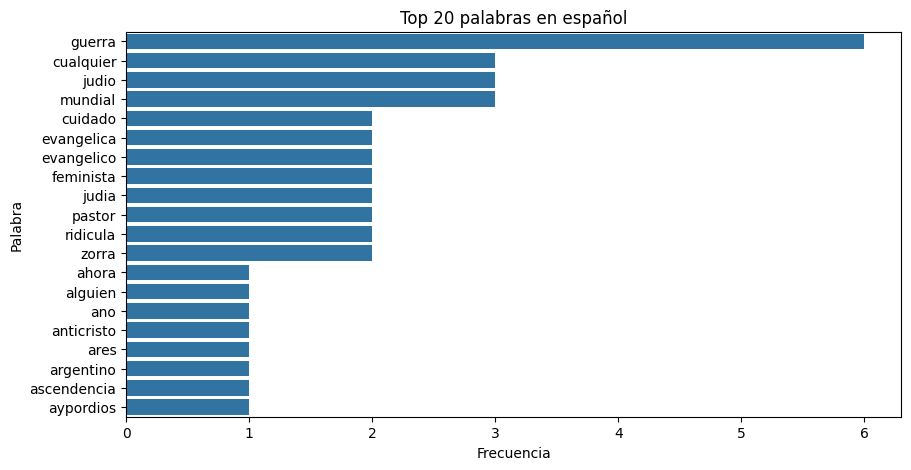

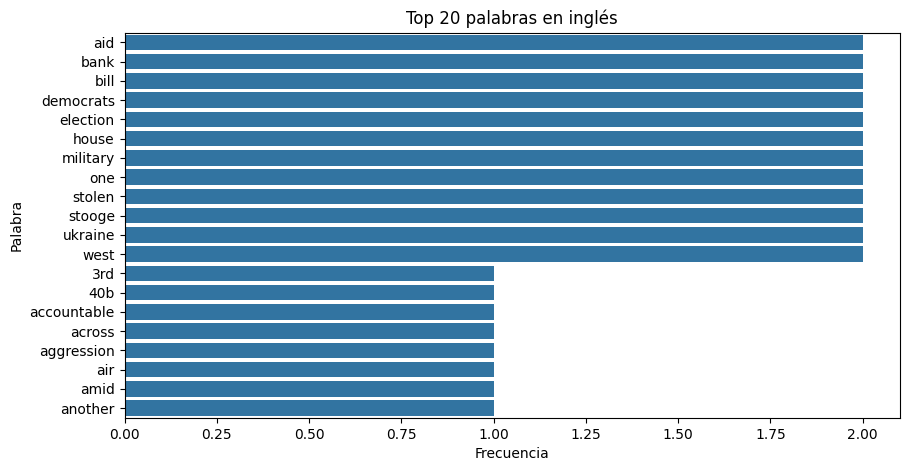

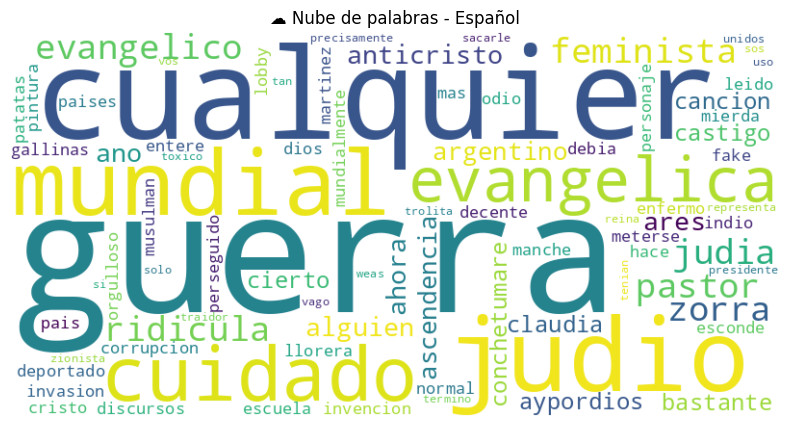

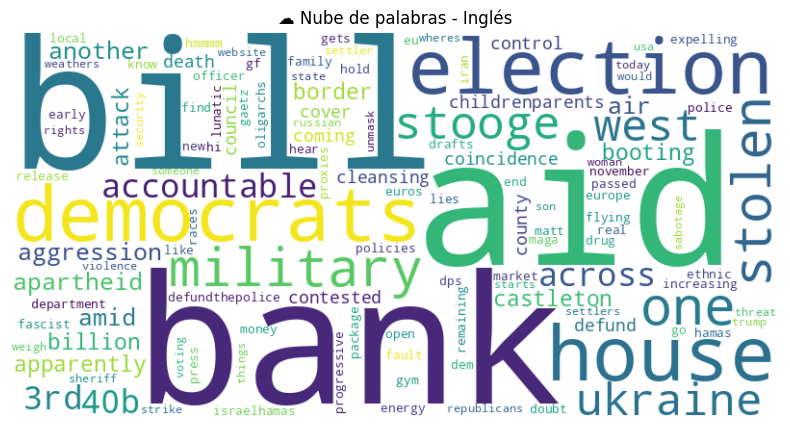

In [ ]:
# ============================================================
# VISUALIZACIONES
# ============================================================

def plot_top_words(freq_dict, title):
    top_words = sorted(freq_dict.items(), key=lambda x: x[1], reverse=True)[:20]
    words, counts = zip(*top_words)
    plt.figure(figsize=(10,5))
    sns.barplot(x=list(counts), y=list(words))
    plt.title(title)
    plt.xlabel("Frecuencia")
    plt.ylabel("Palabra")
    plt.show()

plot_top_words(freq_dist_es, "Top 20 palabras en español")
plot_top_words(freq_dist_en, "Top 20 palabras en inglés")

# --- Nube de palabras ---
def wordcloud_from_freq(freq_dict, title):
    wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(freq_dict)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

wordcloud_from_freq(freq_dist_es, "☁️ Nube de palabras - Español")
wordcloud_from_freq(freq_dist_en, "☁️ Nube de palabras - Inglés")

# Métricas Léxicas y Complejidad

In [ ]:
# ============================================================
# MÉTRICAS LÉXICAS Y COMPLEJIDAD
# ============================================================

def lexical_diversity(texts):
    tokens = [word.lower() for text in texts for word in nltk.word_tokenize(text) if word.isalpha()]
    return len(set(tokens)) / len(tokens) if tokens else 0

def avg_sentence_length(texts):
    sentences = [nltk.sent_tokenize(text) for text in texts]
    lengths = [len(nltk.word_tokenize(s)) for sub in sentences for s in sub]
    return np.mean(lengths) if lengths else 0

# Filtrar por idioma
texts_es = df.loc[df["lang"]=="spa", "text"].astype(str).tolist()
texts_en = df.loc[df["lang"]=="eng", "text"].astype(str).tolist()

# Métricas léxicas básicas
print("\n---  Métricas Léxicas Básicas ---")
print("Diversidad léxica (español):", lexical_diversity(texts_es))
print("Diversidad léxica (inglés):", lexical_diversity(texts_en))
print("Longitud promedio de oraciones (español):", avg_sentence_length(texts_es))
print("Longitud promedio de oraciones (inglés):", avg_sentence_length(texts_en))


---  Métricas Léxicas Básicas ---
Diversidad léxica (español): 0.6424581005586593
Diversidad léxica (inglés): 0.7817258883248731
Longitud promedio de oraciones (español): 7.357142857142857
Longitud promedio de oraciones (inglés): 10.0


# Complejidad Textual

In [ ]:
# ============================================================
# COMPLEJIDAD TEXTUAL AVANZADA (Textstat)
# ============================================================

def text_complexity(texts, lang):
    scores = {
        "Flesch Reading Ease": [],
        "Flesch-Kincaid Grade": [],
        "Dale-Chall": [],
        "Coleman-Liau": [],
        "SMOG Index": []
    }
    for t in texts:
        try:
            scores["Flesch Reading Ease"].append(textstat.flesch_reading_ease(t))
            scores["Flesch-Kincaid Grade"].append(textstat.flesch_kincaid_grade(t))
            scores["Dale-Chall"].append(textstat.dale_chall_readability_score(t))
            scores["Coleman-Liau"].append(textstat.coleman_liau_index(t))
            scores["SMOG Index"].append(textstat.smog_index(t))
        except:
            continue
    df_scores = pd.DataFrame(scores)
    print(f"\n Promedios de complejidad textual - {lang.upper()}:")
    print(df_scores.mean())

text_complexity(texts_es, "español")
text_complexity(texts_en, "inglés")


 Promedios de complejidad textual - ESPAÑOL:
Flesch Reading Ease     51.646067
Flesch-Kincaid Grade     8.099057
Dale-Chall              18.696585
Coleman-Liau             8.193098
SMOG Index               9.263833
dtype: float64

 Promedios de complejidad textual - INGLÉS:
Flesch Reading Ease     48.914494
Flesch-Kincaid Grade     8.921016
Dale-Chall              11.766487
Coleman-Liau            11.264258
SMOG Index              10.324882
dtype: float64


# Comparación

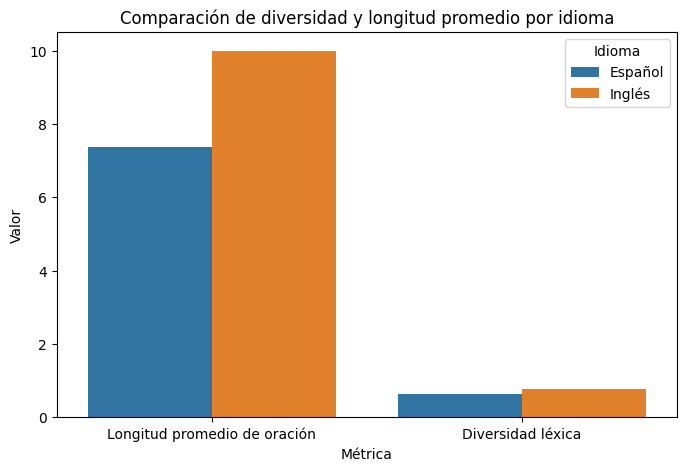

In [ ]:
# ============================================================
# VISUALIZACIÓN COMPARATIVA DE COMPLEJIDAD
# ============================================================

def compare_complexity(texts_es, texts_en):
    data = {
        "Idioma": ["Español", "Inglés"],
        "Longitud promedio de oración": [avg_sentence_length(texts_es), avg_sentence_length(texts_en)],
        "Diversidad léxica": [lexical_diversity(texts_es), lexical_diversity(texts_en)]
    }
    df_comp = pd.DataFrame(data).melt(id_vars="Idioma", var_name="Métrica", value_name="Valor")

    plt.figure(figsize=(8,5))
    sns.barplot(x="Métrica", y="Valor", hue="Idioma", data=df_comp)
    plt.title("Comparación de diversidad y longitud promedio por idioma")
    plt.show()

compare_complexity(texts_es, texts_en)

# Análisis Morfológico


🔍 Distribución morfológica - Español
   Categoría  Proporción
0       NOUN    0.273743
5        ADJ    0.128492
3        DET    0.128492
4        ADP    0.106145
6        ADV    0.083799
7       VERB    0.072626
2        AUX    0.067039
10      PRON    0.055866
1      SCONJ    0.039106
9      PROPN    0.033520
8      CCONJ    0.011173


/tmp/ipython-input-1428612985.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Proporción", y="Categoría", data=pos_df, palette="viridis")


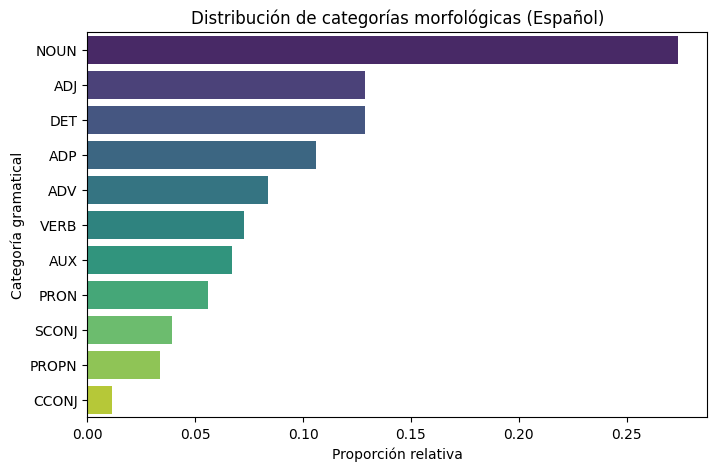


🔍 Distribución morfológica - Inglés
   Categoría  Proporción
5       NOUN    0.247475
1      PROPN    0.166667
3       VERB    0.136364
0        DET    0.111111
6        ADP    0.090909
4        ADJ    0.065657
9       PRON    0.055556
2        AUX    0.040404
11     SCONJ    0.025253
12       ADV    0.020202
10     CCONJ    0.015152
7        NUM    0.015152
8       PART    0.005051
13      INTJ    0.005051


/tmp/ipython-input-1428612985.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Proporción", y="Categoría", data=pos_df, palette="viridis")


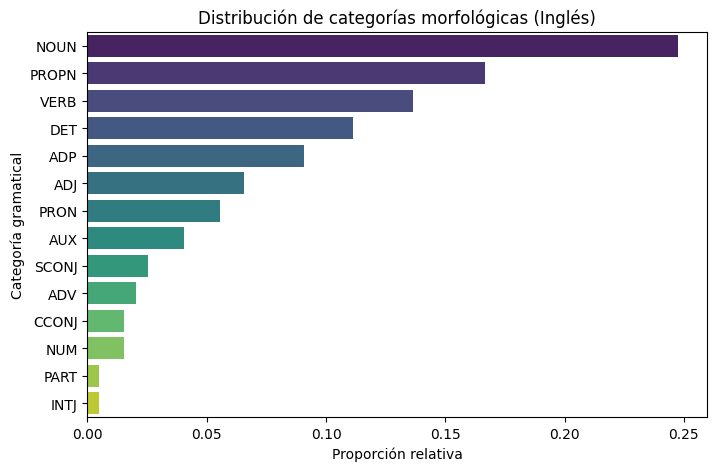

In [ ]:
# ============================================================
#  ANÁLISIS MORFOLÓGICO (Part-of-Speech tagging)
# ============================================================

import spacy
from collections import Counter

# Cargar modelos para español e inglés
nlp_es = spacy.load("es_core_news_sm")
nlp_en = spacy.load("en_core_web_sm")

# Filtrar textos por idioma
texts_es = df.loc[df["lang"] == "spa", "text"].astype(str).tolist()
texts_en = df.loc[df["lang"] == "eng", "text"].astype(str).tolist()

def morph_analysis(texts, nlp_model, lang_name):
    """
    Función para analizar la morfología de una lista de textos.
    Retorna la proporción de tipos de palabras por categoría gramatical.
    """
    pos_counts = Counter()
    total_tokens = 0

    for text in texts[:1000]:  # Limita a 1000 textos para eficiencia
        doc = nlp_model(text)
        pos_counts.update([token.pos_ for token in doc if token.is_alpha])
        total_tokens += len([token for token in doc if token.is_alpha])

    pos_freq = {pos: count / total_tokens for pos, count in pos_counts.items()}
    pos_df = pd.DataFrame(pos_freq.items(), columns=["Categoría", "Proporción"])
    pos_df = pos_df.sort_values(by="Proporción", ascending=False)

    print(f"\n🔍 Distribución morfológica - {lang_name}")
    print(pos_df)

    # Visualización
    plt.figure(figsize=(8,5))
    sns.barplot(x="Proporción", y="Categoría", data=pos_df, palette="viridis")
    plt.title(f"Distribución de categorías morfológicas ({lang_name})")
    plt.xlabel("Proporción relativa")
    plt.ylabel("Categoría gramatical")
    plt.show()

    return pos_df

# Ejecutar análisis morfológico
morph_es = morph_analysis(texts_es, nlp_es, "Español")
morph_en = morph_analysis(texts_en, nlp_en, "Inglés")